# DTEx212. Single particle tracking

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx212_single_particle_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeplay deeptrack  # Uncomment if running on Colab/Kaggle.

This example trains a convolutional neural network with a dense top using simulation data and then applies it to experimental videos of an optically trapped particle.

In [1]:
import deeptrack as dt
import deeplay as dl
import numpy as np
import matplotlib.pyplot as plt
import torch

%matplotlib inline

INFO:numexpr.utils:Note: NumExpr detected 36 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.
/home/iluvatar/anaconda3/lib/python3.9/site-packages/deeptrack/__init__.py:14: UserWarning: TensorFlow is detected in your environment. DeepTrack2 version 2.0++ no longer supports TensorFlow. If you need TensorFlow support, please install the legacy version 1.7 of DeepTrack2:

    pip install deeptrack==1.7

For more details, refer to the DeepTrack documentation.
  warnings.warn(


## 1. Loading the Experimental Videos

Download the `particle_dataset`. This folder contains two videos with an optically trapped particle. One video is acquired with very low noise (`low_noise.avi`), while the other with very high noise (`high_noise.avi`).

In [2]:
import os

if not os.path.exists("particle_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/particle_dataset")


In [3]:
import cv2

def load_video(path, frames_to_load, image_size):
    """Load video."""
    video = cv2.VideoCapture(path)

    data = []
    for _ in range(frames_to_load):
        _, frame = video.read()
        frame = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) / 255
        frame = cv2.resize(frame, (image_size, image_size))
        data.append(frame)

    return np.array(data)


In [4]:
image_size = 51
video_low_noise = load_video(
    os.path.join("particle_dataset", "low_noise.avi"),
    frames_to_load=100,
    image_size=image_size,
)
video_high_noise = load_video(
    os.path.join("particle_dataset", "high_noise.avi"),
    frames_to_load=100,
    image_size=image_size,
)


... and plot some of the frames.

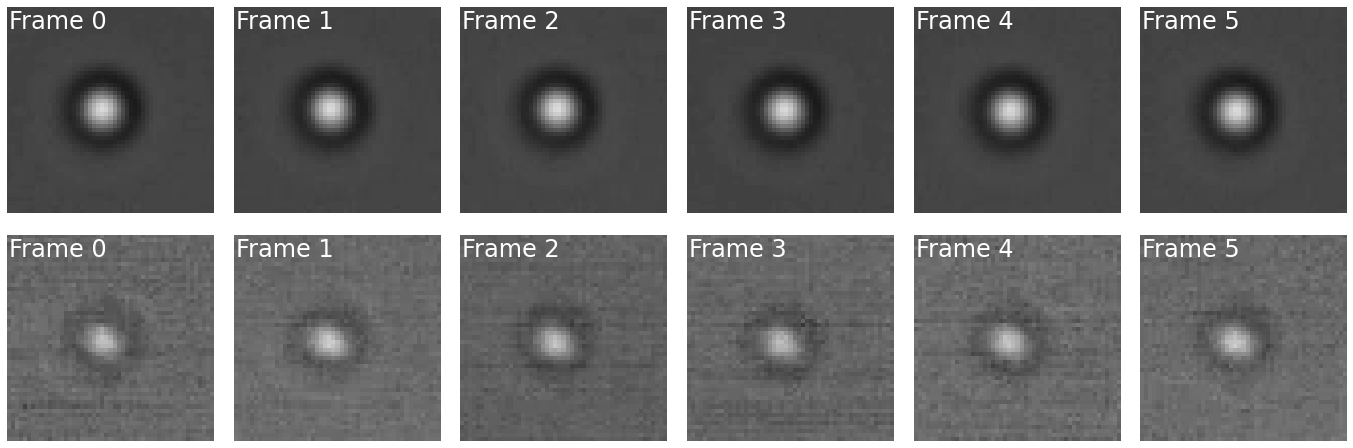

In [5]:
fig, axs = plt.subplots(2, 6, figsize=(24, 8))
for i in range(6):
    axs[0, i].imshow(video_low_noise[i], cmap="gray", vmin=0, vmax=1)
    axs[0, i].text(0, 5, f"Frame {i}", color="white", fontsize=24)
    axs[0, i].axis("off")

    axs[1, i].imshow(video_high_noise[i], cmap="gray", vmin=0, vmax=1)
    axs[1, i].text(0, 5, f"Frame {i}", color="white", fontsize=24)
    axs[1, i].axis("off")
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()


## 2. Defining the Simulation Dataset

### 2.1. Defining the training set

The training set consists of simulated 51 by 51 pixel images (the same size as the experimantal video), containing a single particle each. The particles are simulated as spheres with a radius between 1 micron and 2 microns, and a refractive index between 1.37 and 1.42. Its position in the camera plane is constrained to be within the image, and is sampled with a normal distribution with standard deviation of 5 pixel units in along the axis normal to the camera plane.

In [6]:
particle = dt.scatterers.MieSphere(
    position=lambda: np.random.uniform(image_size / 2 - 5, image_size / 2 + 5, 2) * dt.units.pixel,
    z=lambda: np.random.uniform(-1, 1) * dt.units.pixel,
    radius=lambda: np.random.uniform(500, 600) * 1e-9,
    refractive_index=lambda: np.random.uniform(1.37, 1.42),
    position_unit="pixel",
)


The particle is imaged using a brightfield microscope with NA of 0.8 and a illuminating laser wavelength of 630 nm. To simulate the broad spectrum we define 10 individual optical devices, each imaging the particle at a single wavelength. The result is then averaged.

In [7]:
brightfield_microscope = dt.Brightfield(
    NA=0.8,
    resolution=1e-6,
    magnification=15,
    wavelength=630 * 1e-9,
    refractive_index_medium=1.33,
    padding=(32, 32, 32, 32),
    output_region=(0, 0, image_size, image_size),
)

dataset = brightfield_microscope(particle)
dataset.store_properties()


### 2.2. Defining the training label

The training label is extracted directly from the image as the `position` property divided by the image size, such that the posible values are contained within -0.5 and 0.5.

In [8]:
def get_label(image):
    px = np.array(image.get_property("position")) / image_size - 0.5
    return px


### 2.3. Visualizing the dataset

We resolve and show 6 images, with a green circle indicating the particle position.

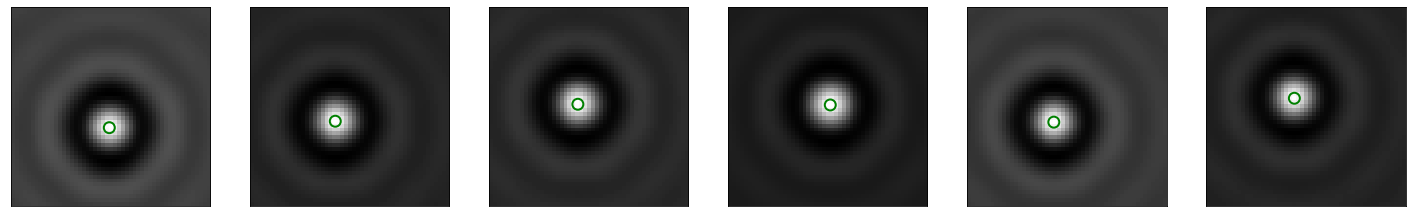

In [9]:
number_of_images = 6

fig, axs = plt.subplots(1, number_of_images, figsize=(25, 8))
for i, ax in enumerate(axs.flatten()):
    dataset.update()
    image_of_particle = dataset()
    position_of_particle = get_label(image_of_particle) * image_size + image_size / 2
    ax.imshow(image_of_particle[..., 0], cmap="gray")
    ax.scatter(
        position_of_particle[1],
        position_of_particle[0],
        s=120,
        facecolors="none",
        edgecolors="g",
        linewidth=2,
    )
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


### 2.4. Augmenting dataset

Simulating mie particles is slow. To speed up training we implement augmentation techniques. Here we flip and mirror the image. Note that DeepTrack ensures that the position is still correct after the augmentation.

In [10]:
augmented_dataset = dt.Reuse(dataset, 8) >> dt.FlipLR() >> dt.FlipUD() >> dt.FlipDiagonal()

We add noises after augmentation. This allows the augmented images to be more distinct.

In [11]:
gradient = dt.IlluminationGradient(
    gradient=lambda: np.random.randn(2) * 1e-4,
)

noise = dt.Poisson(
    min_snr=5,
    max_snr=100,
    snr=lambda min_snr, max_snr: min_snr + np.random.rand() * (max_snr - min_snr),
    background=1,
)

normalization = dt.NormalizeMinMax(
    lambda: np.random.rand() * 0.2, lambda: 0.8 + np.random.rand() * 0.2
)

data_pipeline = augmented_dataset >> gradient >> noise >> normalization

data_pipeline.store_properties()


We resolve and show 6 images, with a green circle indicating the particle position.

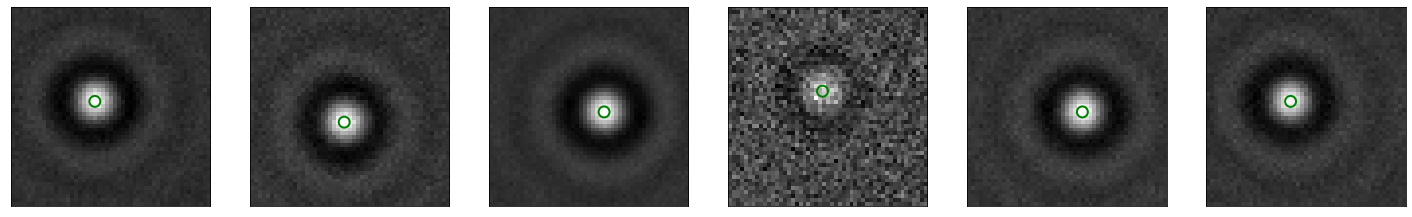

In [12]:
number_of_images = 6

fig, axs = plt.subplots(1, number_of_images, figsize=(25, 8))
for i, ax in enumerate(axs.flatten()):
    data_pipeline.update()
    image_of_particle = data_pipeline()
    position_of_particle = get_label(image_of_particle) * image_size + image_size / 2
    ax.imshow(image_of_particle[..., 0], cmap="gray")
    ax.scatter(
        position_of_particle[1],
        position_of_particle[0],
        s=120,
        facecolors="none",
        edgecolors="g",
        linewidth=2,
    )
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


## 3. Defining the network

Define a convolutional neural network with a dense top ...

In [13]:
cnn = dl.Sequential(
    dl.ConvolutionalNeuralNetwork(
        in_channels=1,
        hidden_channels=[16, 32],
        out_channels=64,
        pool=torch.nn.MaxPool2d(kernel_size=2),
        out_activation=torch.nn.ReLU,
    ),
    dl.Layer(torch.nn.MaxPool2d, kernel_size=2),
    dl.Layer(torch.nn.Flatten),
    dl.MultiLayerPerceptron(
        in_features=6 * 6 * 64,
        hidden_features=[32, 32],
        out_features=2,
        out_activation=torch.nn.Identity,
    ),
)

print(cnn)


Sequential(
  (0): ConvolutionalNeuralNetwork(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Layer[Conv2d](in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (1): Conv2dBlock(
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (layer): Layer[Conv2d](in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (2): Conv2dBlock(
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (layer): Layer[Conv2d](in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
    )
  )
  (1): Layer[MaxPool2d](kernel_size=2)
  (2): Layer[Flatten]()
  (3): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Layer[Linear](in_features=2304, out_features=32, bias=True)
        (activa

... and compile it for a regression task.

In [14]:
from torchmetrics import MeanAbsoluteError as MAE

cnn_regressor_template = dl.Regressor(
    model=cnn,
    loss=torch.nn.MSELoss(),
    optimizer=dl.Adam(),
    metrics=[MAE()],
)
cnn_sim_regressor = cnn_regressor_template.create()

print(cnn_sim_regressor)


INFO:torch.distributed.nn.jit.instantiator:Created a temporary directory at /tmp/tmpx_45_d_8
INFO:torch.distributed.nn.jit.instantiator:Writing /tmp/tmpx_45_d_8/_remote_module_non_scriptable.py


Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam]()
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64,

## 4. Training the network

Define a custom dataset ...

In [15]:
class SimulatedDataset(torch.utils.data.Dataset):
    """Dataset with simulated particles."""

    def __init__(self, pipeline, data_size):
        """Initialize simulated dataset."""
        images, positions = [], []
        for _ in range(data_size):
            image = data_pipeline.update().resolve()
            position = image.get_property("position")
            images.append(image), positions.append(position[[1, 0]])
        self.images, self.imges_, self.positions = np.array(images), images, np.array(positions)

    def __len__(self):
        """Return number of images."""
        return self.images.shape[0]

    def __getitem__(self, idx):
        """Get next simulated image and position."""
        im = torch.tensor(self.images[idx]).float().permute(2, 0, 1)
        pos = torch.tensor(self.positions[idx] / im.shape[-1] - 0.5).float()
        return [im, pos]


... and use it to create the train data and test data loaders.



In [16]:
train_sim_dataloader = dl.DataLoader(
    SimulatedDataset(pipeline=data_pipeline, data_size=3000),
    batch_size=32,
)
test_sim_dataloader = dl.DataLoader(
    SimulatedDataset(pipeline=data_pipeline, data_size=1000),
    batch_size=32,
)


Train the neural network regressor with simulation data.

In [17]:
cnn_sim_trainer = dl.Trainer(max_epochs=50, accelerator="auto")
cnn_sim_trainer.fit(cnn_sim_regressor, train_sim_dataloader)


/home/iluvatar/anaconda3/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
2025-06-25 00:26:13.228780: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │
│ 4 │ model         │ Sequential       │ 98.2 K │ train │
│ 5 │ optimizer     │ Adam             │      0 │ train │
└───┴───────────────┴──────────────────┴────────┴───────┘

Trainable params: 98.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 98.2 K                                                                                               
Total estimated model params size (MB): 0

Output()

/home/iluvatar/anaconda3/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=35` in the `DataLoader` to improve performance.


## 5. Evaluating the network

### 5.1. Testing the Trained Neural Network


We can calculate the mean pixel error (MAE) in train dataset ...

In [18]:
train_sim_results = cnn_sim_trainer.test(cnn_sim_regressor, train_sim_dataloader)
MAE_sim = train_sim_results[0]["testMeanAbsoluteError_epoch"] * image_size
print(f"Mean pixel error (MAE) for train dataset: {MAE_sim:.3f} pixels")


Output()

/home/iluvatar/anaconda3/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=35` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.0015865963650867343    │
│       test_loss_epoch       │   4.0563759284850676e-06    │
└─────────────────────────────┴─────────────────────────────┘

Mean pixel error (MAE) for train dataset: 0.081 pixels


... as well as the test dataset.

In [19]:
test_sim_results = cnn_sim_trainer.test(cnn_sim_regressor, test_sim_dataloader)
MAE_sim = test_sim_results[0]["testMeanAbsoluteError_epoch"] * image_size
print(f"Mean pixel error (MAE) for test dataset: {MAE_sim:.3f} pixels")


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.001787884975783527     │
│       test_loss_epoch       │    5.270881956676021e-06    │
└─────────────────────────────┴─────────────────────────────┘

Mean pixel error (MAE) for test dataset: 0.091 pixels


### 5.2. Prediction vs actual

We can also show the prediction of each output versus the ground truth in train dataset ...

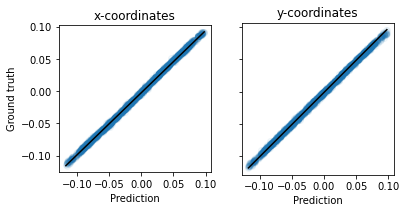

In [20]:
preds, gts = [], []
for image, position in iter(train_sim_dataloader):
    preds.append(cnn_sim_regressor(image))
    gts.append(position)
preds = torch.cat(preds, dim=0).detach().numpy()
gts = torch.cat(gts, dim=0).numpy()

fig, axs = plt.subplots(1, 2)
for i, ax, coordinate in zip([0, 1], axs, ["x", "y"]):
    gt, pred = gts[:][:, i], preds[:][:, i]
    ax.scatter(gt, pred, alpha=0.05)
    ax.plot([np.min(gt), np.max(gt)], [np.min(pred), np.max(pred)], c="k")
    ax.set_title(f"{coordinate}-coordinates")
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Ground truth")
    ax.set_aspect("equal")
    ax.label_outer()
plt.show()


... as well as the test dataset.

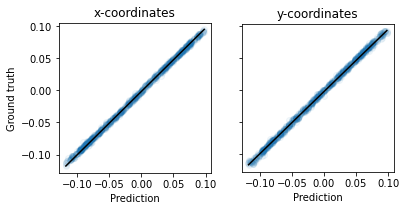

In [21]:
preds, gts = [], []
for image, position in iter(test_sim_dataloader):
    preds.append(cnn_sim_regressor(image))
    gts.append(position)
preds = torch.cat(preds, dim=0).detach().numpy()
gts = torch.cat(gts, dim=0).numpy()

fig, axs = plt.subplots(1, 2)
for i, ax, coordinate in zip([0, 1], axs, ["x", "y"]):
    gt, pred = gts[:][:, i], preds[:][:, i]
    ax.scatter(gt, pred, alpha=0.05)
    ax.plot([np.min(gt), np.max(gt)], [np.min(pred), np.max(pred)], c="k")
    ax.set_title(f"{coordinate}-coordinates")
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Ground truth")
    ax.set_aspect("equal")
    ax.label_outer()
plt.show()


### 5.3. Prediction vs property value

We show the the pixel error as a function of some properties.

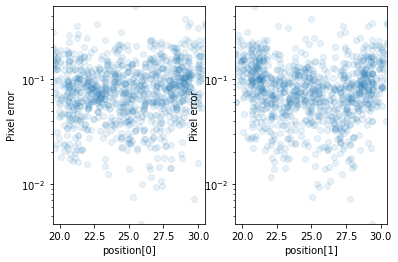

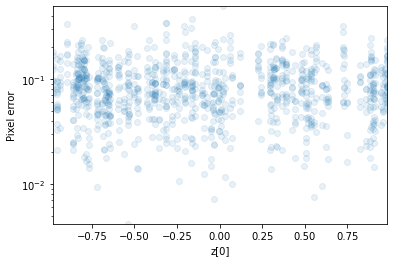

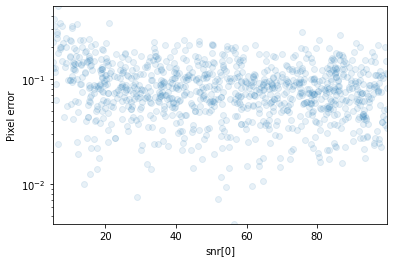

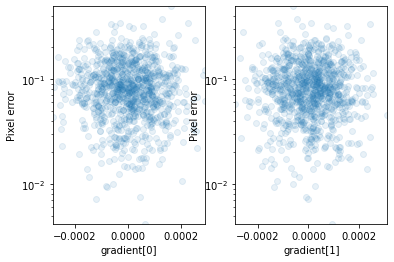

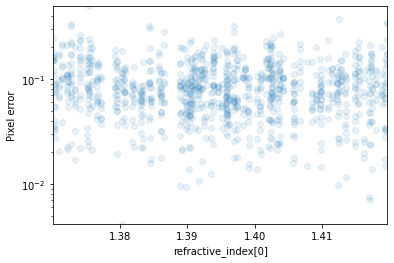

In [22]:
properties = ["position", "z", "snr", "gradient", "refractive_index"]
snr = [image.get_property("snr") for image in test_sim_dataloader.dataset.imges_]

preds, gts = [], []
for image, position in iter(test_sim_dataloader):
    preds.append(cnn_sim_regressor(image))
    gts.append(position)
preds = torch.cat(preds, dim=0).detach().numpy()
gts = torch.cat(gts, dim=0).numpy()

test_error = np.mean(np.abs(preds - gts), axis=-1) * image_size

for property_name in properties:
    property_values = np.array(
        [
            image.get_property(property_name)
            for image in test_sim_dataloader.dataset.imges_
        ]
    )
    if property_values.ndim == 1:
        property_values = np.expand_dims(property_values, axis=-1)

    for col in range(property_values.shape[1]):
        values = property_values[:, col]

        plt.subplot(1, property_values.shape[1], col + 1)

        plt.scatter(values, test_error, alpha=0.1)
        plt.xlim([np.min(values), np.max(values)])
        plt.ylim([np.min(test_error), np.max(test_error)])
        plt.yscale("log")
        plt.ylabel("Pixel error")
        plt.xlabel("{0}[{1}]".format(property_name, col))

    plt.show()


### 5.4. Experimental data
We apply the trained model to two experomental videos with high noise and low noise.

Define a custom dataset for experimental video...

In [23]:
class ExperimantalDataset(torch.utils.data.Dataset):
    """Experimental dataset."""

    def __init__(self, data_images):
        """Load experimantal images"""
        self.images = data_images

    def __len__(self):
        """Return number of images."""
        return self.images.shape[0]

    def __getitem__(self, idx):
        """Get next image."""
        im = torch.tensor(self.images[idx, np.newaxis, :, :]).float()
        return im


... and use it to create the low noise real data and high noise data loaders.

In [24]:
video_low_noise_dataloader = dl.DataLoader(
    ExperimantalDataset(data_images=video_low_noise),
    batch_size=32,
)
video_high_noise_dataloader = dl.DataLoader(
    ExperimantalDataset(data_images=video_high_noise),
    batch_size=32,
)


Use the trained model to predict the particle position in low noise video ...

In [25]:
preds = []
for image in iter(video_low_noise_dataloader):
    preds.append(cnn_sim_regressor(image))
preds = torch.cat(preds, dim=0).detach().numpy()
preds = preds * image_size + image_size / 2


... and display the result.

In [26]:
%matplotlib notebook

import matplotlib.animation as animation
from IPython.display import HTML

fig, ax1 = plt.subplots()

x = np.linspace(0, 2 * np.pi, 100)
ax1.imshow(video_low_noise[0], cmap="gray")
(point,) = ax1.plot(preds[0:1, 0], preds[0:1, 1], c="r", marker="o")


def init():
    ax1.imshow(video_low_noise[0], cmap="gray")
    point.set_data(preds[0:1, 0], preds[0:1, 1])
    return point


def animate(idx):
    ax1.imshow(video_low_noise[idx], cmap="gray")
    point.set_data(preds[idx : idx + 1, 0], preds[idx : idx + 1, 1])
    return point


ani = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=video_low_noise.shape[0],
    interval=50,
    blit=True,
)

HTML(ani.to_jshtml())


<IPython.core.display.Javascript object>

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


Use the trained model to predict the particle position in high noise video ...

In [27]:
preds = []
for image in iter(video_high_noise_dataloader):
    preds.append(cnn_sim_regressor(image))
preds = torch.cat(preds, dim=0).detach().numpy()
preds = preds * image_size + image_size / 2


... and display the result.

In [28]:
fig, ax1 = plt.subplots()

x = np.linspace(0, 2 * np.pi, 100)
ax1.imshow(video_high_noise[0], cmap="gray")
(point,) = ax1.plot(preds[0:1, 0], preds[0:1, 1], c="r", marker="o")


def init():
    ax1.imshow(video_high_noise[0], cmap="gray")
    point.set_data(preds[0:1, 0], preds[0:1, 1])
    return point


def animate(idx):
    ax1.imshow(video_high_noise[idx], cmap="gray")
    point.set_data(preds[idx : idx + 1, 0], preds[idx : idx + 1, 1])
    return point


ani = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=video_high_noise.shape[0],
    interval=50,
    blit=True,
)

HTML(ani.to_jshtml())


<IPython.core.display.Javascript object>

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>
